Tỷ lệ xác suất đã được kẹp (clipped)
Bạn sẽ hiện thực tỷ lệ xác suất đã được kẹp (clipped probability ratio), một thành phần cốt lõi của hàm mục tiêu PPO.

Tham chiếu: tỷ lệ xác suất được định nghĩa là:

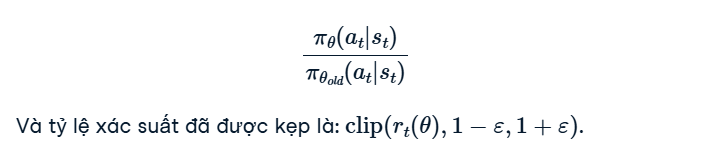

Hướng dẫn
100 XP
Lấy xác suất hành động prob từ action_log_prob, và prob_old từ action_log_prob_old.
Tách log prob hành động cũ khỏi đồ thị gradient của torch.
Tính tỷ lệ xác suất.
Kẹp (clip) mục tiêu thay thế (surrogate objective).

In [ ]:
log_prob = torch.tensor(.5).log()
log_prob_old = torch.tensor(.4).log()

def calculate_ratios(action_log_prob, action_log_prob_old, epsilon):
    # Obtain prob and prob_old
    prob = ____
    prob_old = ____
    # Detach the old action log prob
    prob_old_detached = ____.____()
    # Calculate the probability ratio
    ratio = ____ / ____
    # Apply clipping
    clipped_ratio = torch.____(ratio, ____, ____)
    print(f"+{'-'*29}+\n|         Ratio: {str(ratio)} |\n| Clipped ratio: {str(clipped_ratio)} |\n+{'-'*29}+\n")
    return (ratio, clipped_ratio)

_ = calculate_ratios(log_prob, log_prob_old, epsilon=.2)

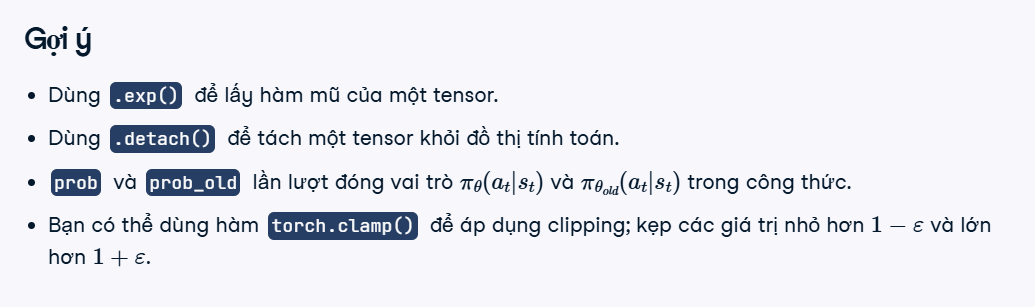

In [ ]:
"""
log_prob = torch.tensor(.5).log()
log_prob_old = torch.tensor(.4).log()

def calculate_ratios(action_log_prob, action_log_prob_old, epsilon):
    # Obtain prob and prob_old
    prob = action_log_prob.exp()
    prob_old = action_log_prob_old.exp()
    # Detach the old action log prob
    prob_old_detached = prob_old.detach()
    # Calculate the probability ratio
    ratio = prob / prob_old_detached
    # Apply clipping
    clipped_ratio = torch.clamp(ratio, 1-epsilon, 1+epsilon)
    print(f"+{'-'*29}+\n|         Ratio: {str(ratio)} |\n| Clipped ratio: {str(clipped_ratio)} |\n+{'-'*29}+\n")
    return (ratio, clipped_ratio)

_ = calculate_ratios(log_prob, log_prob_old, epsilon=.2)

"""

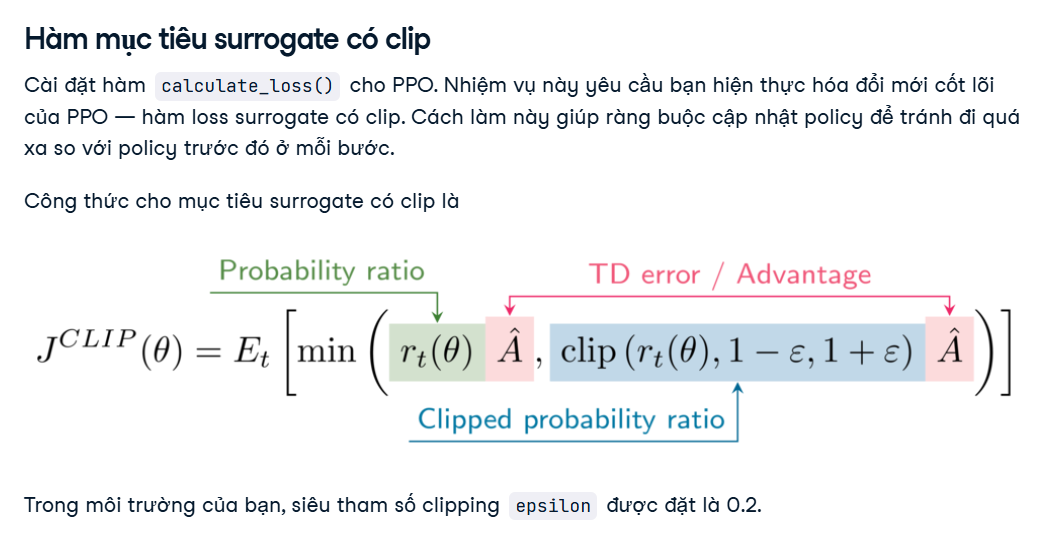

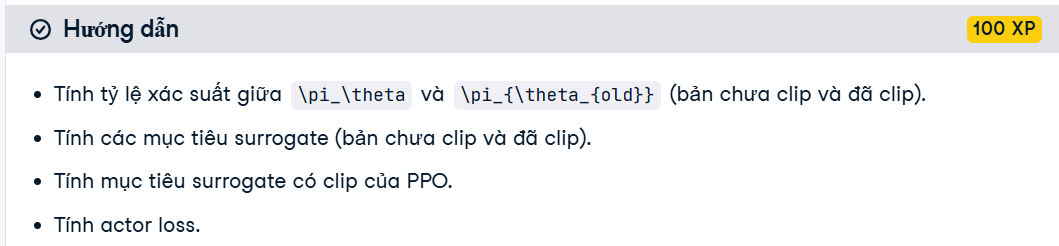



In [1]:
def calculate_losses(critic_network, action_log_prob, action_log_prob_old,
                     reward, state, next_state, done):
    value = critic_network(state)
    next_value = critic_network(next_state)
    td_target = (reward + gamma * next_value * (1-done))
    td_error = td_target - value
    # Obtain the probability ratios
    ____, ____ = calculate_ratios(action_log_prob, action_log_prob_old, epsilon=.2)
    # Calculate the surrogate objectives
    surr1 = ratio * ____.____()
    surr2 = clipped_ratio * ____.____()    
    # Calculate the clipped surrogate objective
    objective = torch.min(____, ____)
    # Calculate the actor loss
    actor_loss = ____
    critic_loss = td_error ** 2
    return actor_loss, critic_loss
  
actor_loss, critic_loss = calculate_losses(critic_network, action_log_prob, action_log_prob_old,
                                           reward, state, next_state, done)
print(actor_loss, critic_loss)

NameError: name 'critic_network' is not defined

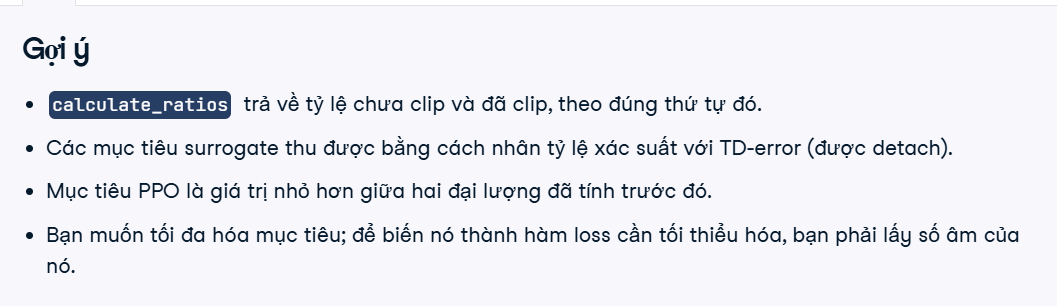

In [ ]:
"""
def calculate_losses(critic_network, action_log_prob, action_log_prob_old,
                     reward, state, next_state, done):
    value = critic_network(state)
    next_value = critic_network(next_state)
    td_target = (reward + gamma * next_value * (1-done))
    td_error = td_target - value
    # Obtain the probability ratios
    ratio, clipped_ratio = calculate_ratios(action_log_prob, action_log_prob_old, epsilon=.2)
    # Calculate the surrogate objectives
    surr1 = ratio * td_error.detach()
    surr2 = clipped_ratio * td_error.detach()    
    # Calculate the clipped surrogate objective
    objective = torch.min(surr1, surr2)
    # Calculate the actor loss
    actor_loss = -objective
    critic_loss = td_error ** 2
    return actor_loss, critic_loss
  
actor_loss, critic_loss = calculate_losses(critic_network, action_log_prob, action_log_prob_old,
                                           reward, state, next_state, done)
print(actor_loss, critic_loss)

"""

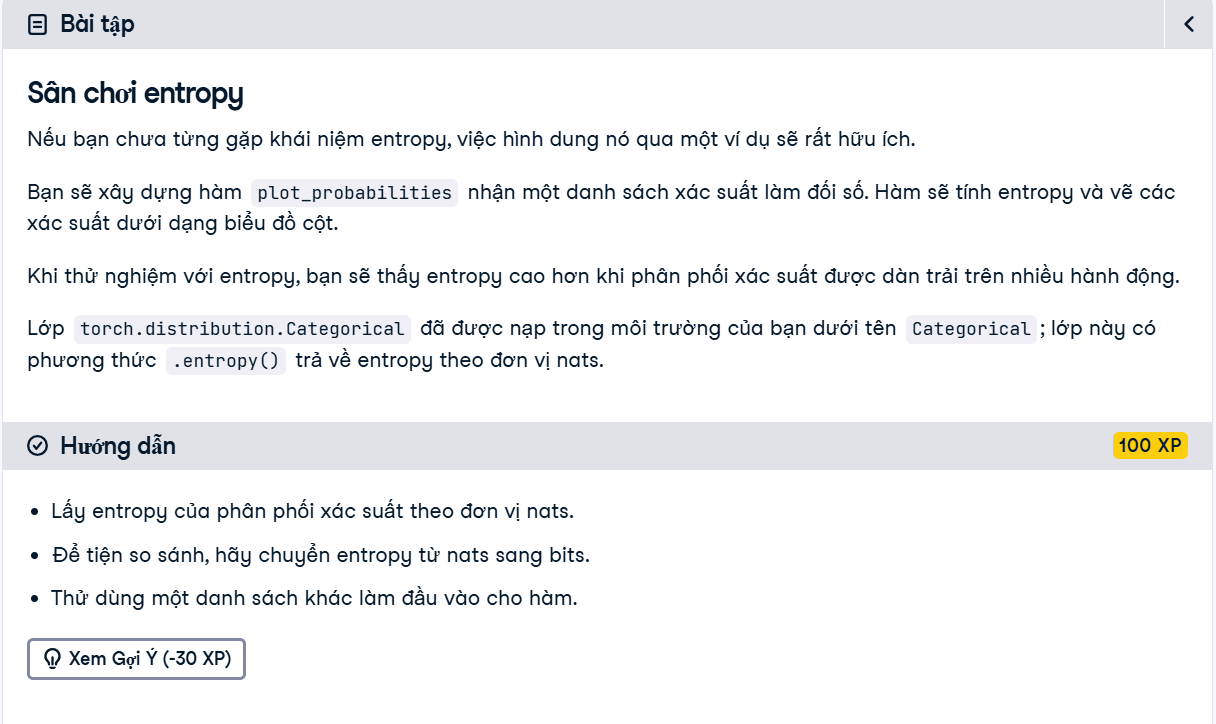

In [2]:
def plot_probabilities(probs):
  dist = Categorical(torch.tensor(probs))
  # Obtain the entropy in nats
  entropy = dist.____
  # Convert the entropy to bits
  entropy = entropy / math.log(____)
  print(f"{'Probabilities:':>15} {[round(prob, 3) for prob in dist.probs.tolist()]}")
  print(f"{'Entropy:':>15} {entropy:.2f}\n")
  plt.figure()
  plt.bar([str(x) for x in range(len(dist.probs))], dist.probs, color='skyblue', edgecolor='black')
  plt.ylabel('Probability'); plt.xlabel('Action index'); plt.ylim(0, 1)
  plt.show()
  
plot_probabilities([.25, .25, .25, .25])
plot_probabilities([.1, .15, .2, .25, .3])
# Try with your own list
plot_probabilities(____)

NameError: name 'Categorical' is not defined

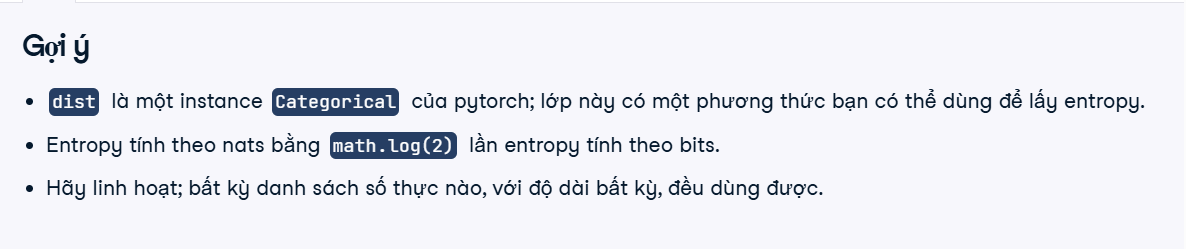

In [ ]:
"""
def plot_probabilities(probs):
  dist = Categorical(torch.tensor(probs))
  # Obtain the entropy in nats
  entropy = dist.entropy()
  # Convert the entropy to bits
  entropy = entropy / math.log(2)
  print(f"{'Probabilities:':>15} {[round(prob, 3) for prob in dist.probs.tolist()]}")
  print(f"{'Entropy:':>15} {entropy:.2f}\n")
  plt.figure()
  plt.bar([str(x) for x in range(len(dist.probs))], dist.probs, color='skyblue', edgecolor='black')
  plt.ylabel('Probability'); plt.xlabel('Action index'); plt.ylim(0, 1)
  plt.show()
  
plot_probabilities([.25, .25, .25, .25])
plot_probabilities([.1, .15, .2, .25, .3])
# Try with your own list
plot_probabilities([.5, .5])

"""

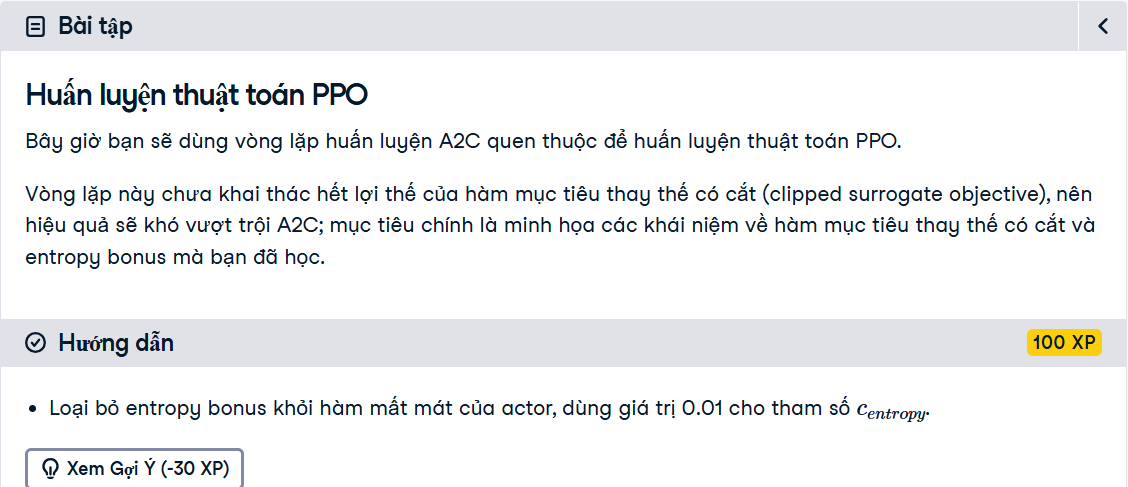

In [ ]:
for episode in range(10):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    while not done:    
        step += 1
        action, action_log_prob, entropy = select_action(actor, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        done = terminated or truncated
        actor_loss, critic_loss = calculate_losses(critic, action_log_prob, action_log_prob,
                                                   reward, state, next_state, done)
        # Remove the entropy bonus from the actor loss
        actor_loss -= ____ * ____
        actor_optimizer.zero_grad(); actor_loss.backward(); actor_optimizer.step()
        critic_optimizer.zero_grad(); critic_loss.backward(); critic_optimizer.step()
        state = next_state
    describe_episode(episode, reward, episode_reward, step)

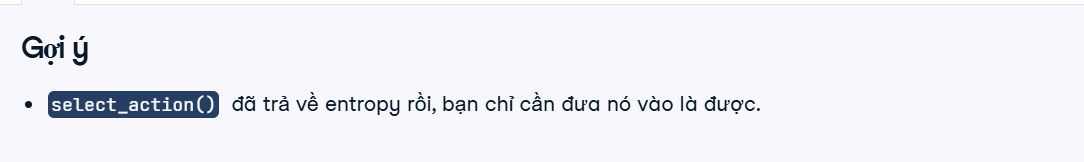

In [ ]:
"""for episode in range(10):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    while not done:    
        step += 1
        action, action_log_prob, entropy = select_action(actor, state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode_reward += reward
        done = terminated or truncated
        actor_loss, critic_loss = calculate_losses(critic, action_log_prob, action_log_prob,
                                                   reward, state, next_state, done)
        # Remove the entropy bonus from the actor loss
        actor_loss -= 0.01 * entropy
        actor_optimizer.zero_grad(); actor_loss.backward(); actor_optimizer.step()
        critic_optimizer.zero_grad(); critic_loss.backward(); critic_optimizer.step()
        state = next_state
    describe_episode(episode, reward, episode_reward, step)
    """

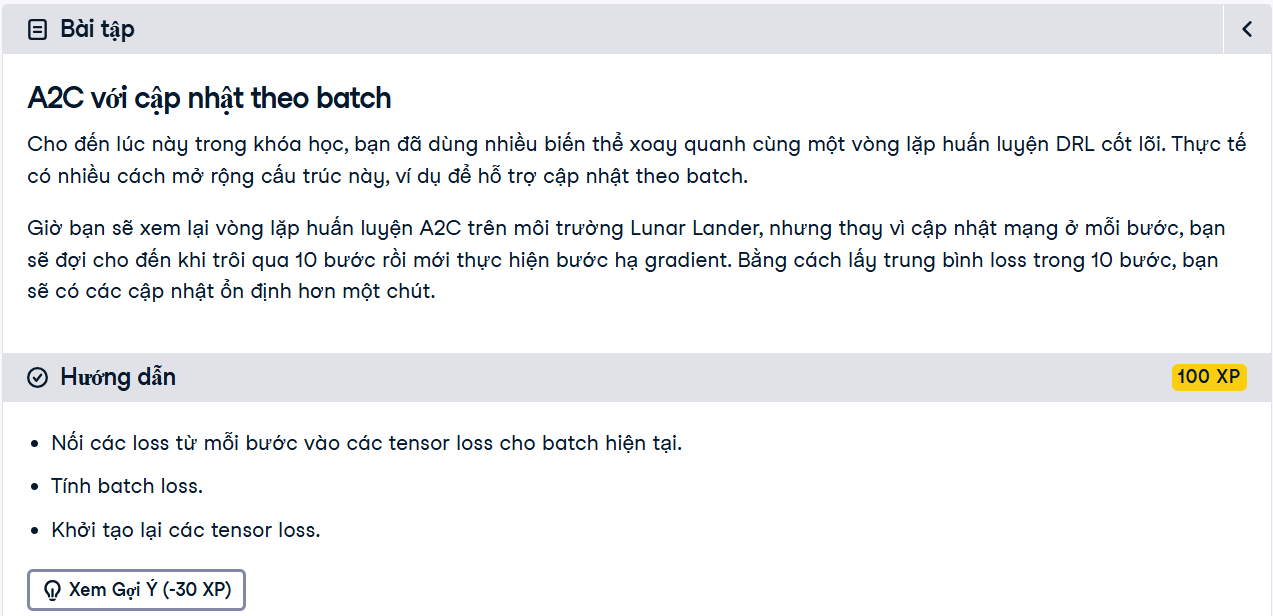

In [3]:
actor_losses = torch.tensor([])
critic_losses = torch.tensor([])
for episode in range(10):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    while not done:
        step += 1
        action, action_log_prob = select_action(actor, state)                
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        actor_loss, critic_loss = calculate_losses(
            critic, action_log_prob, 
            reward, state, next_state, done)
        # Append to the loss tensors
        actor_losses = torch.cat((____, ____))
        critic_losses = torch.cat((____, ____))
        if len(actor_losses) >= 10:
            # Calculate the batch losses
            actor_loss_batch = actor_losses.____
            critic_loss_batch = critic_losses.____
            actor_optimizer.zero_grad(); actor_loss_batch.backward(); actor_optimizer.step()
            critic_optimizer.zero_grad(); critic_loss_batch.backward(); critic_optimizer.step()
            # Reinitialize the loss tensors
            actor_losses = ____
            critic_losses = ____
        state = next_state
    describe_episode(episode, reward, episode_reward, step)

NameError: name 'torch' is not defined

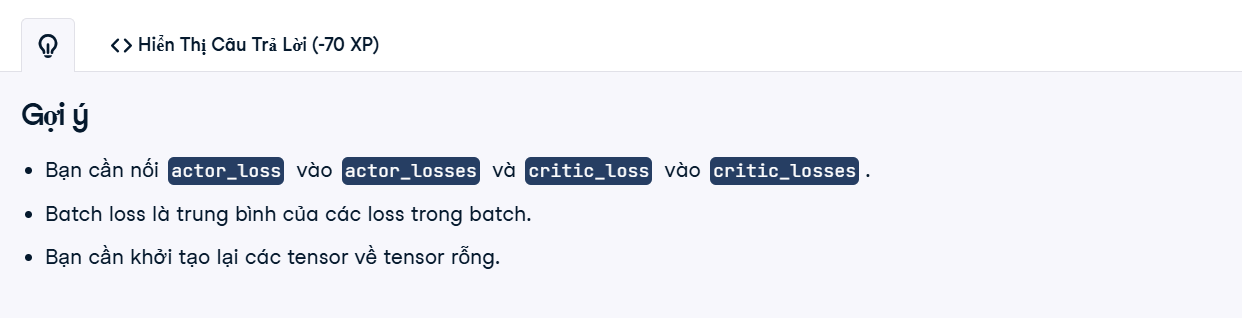

In [ ]:
"""
actor_losses = torch.tensor([])
critic_losses = torch.tensor([])
for episode in range(10):
    state, info = env.reset()
    done = False
    episode_reward = 0
    step = 0
    while not done:
        step += 1
        action, action_log_prob = select_action(actor, state)                
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        episode_reward += reward
        actor_loss, critic_loss = calculate_losses(
            critic, action_log_prob, 
            reward, state, next_state, done)
        # Append to the loss tensors
        actor_losses = torch.cat((actor_losses, actor_loss))
        critic_losses = torch.cat((critic_losses, critic_loss))
        if len(actor_losses) >= 10:
            # Calculate the batch losses
            actor_loss_batch = actor_losses.mean()
            critic_loss_batch = critic_losses.mean()
            actor_optimizer.zero_grad(); actor_loss_batch.backward(); actor_optimizer.step()
            critic_optimizer.zero_grad(); critic_loss_batch.backward(); critic_optimizer.step()
            # Reinitialize the loss tensors
            actor_losses = torch.tensor([])
            critic_losses = torch.tensor([])
        state = next_state
    describe_episode(episode, reward, episode_reward, step)
    """

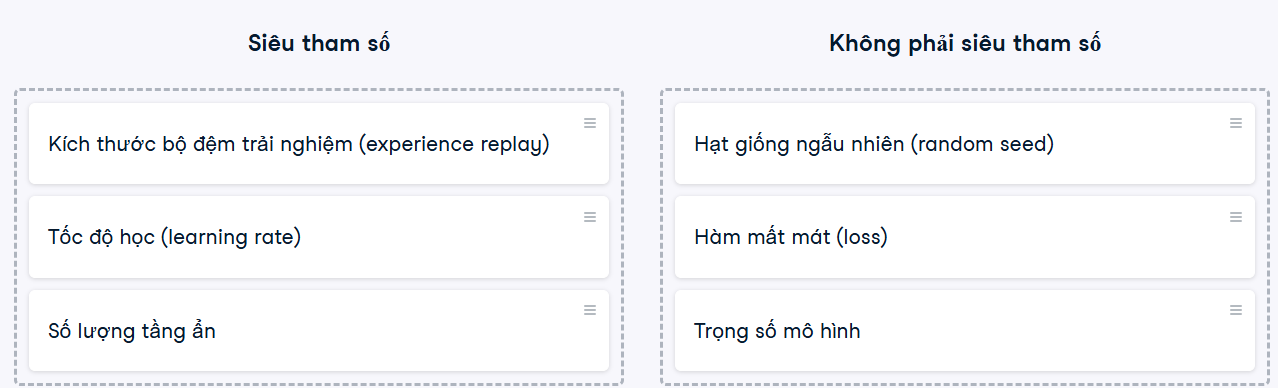

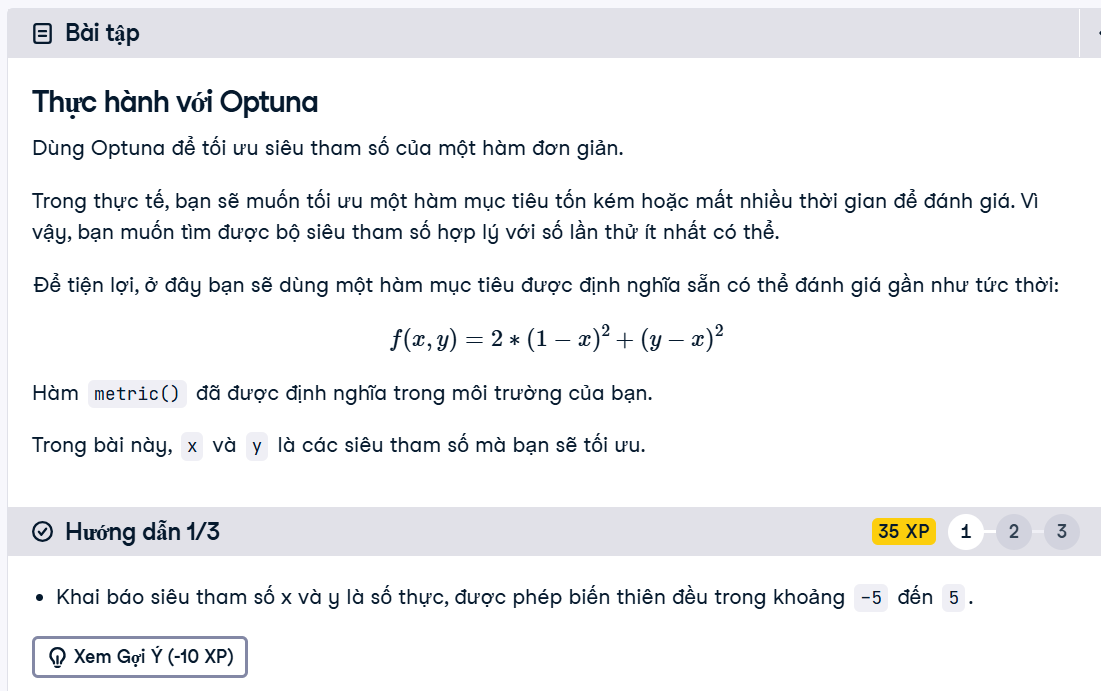

In [ ]:
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = ____
    y = ____
    
    value = metric(x, y)
    return value

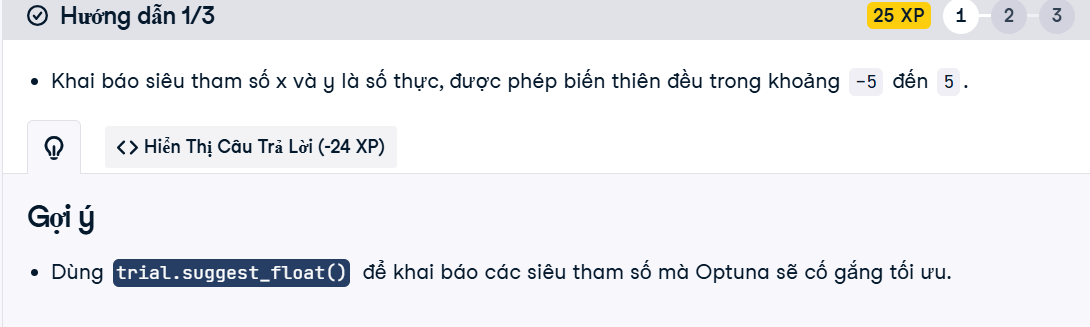

In [ ]:
"""
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = trial.suggest_float('x', -5, 5)
    y = trial.suggest_float('y', -5, 5)
    
    value = metric(x, y)
    return value
    
    """

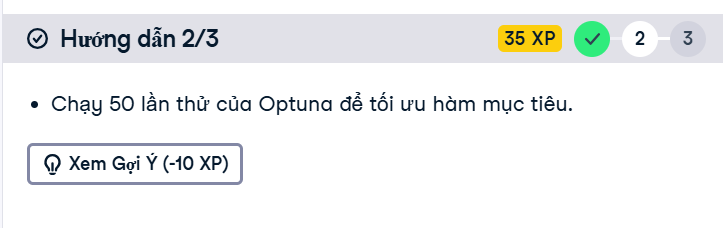

In [ ]:
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = trial.suggest_float('x', -5, 5)
    y = trial.suggest_float('y', -5, 5)
    
    value = metric(x, y)
    return value

# Run 50 trials to optimize the objective function
study.____

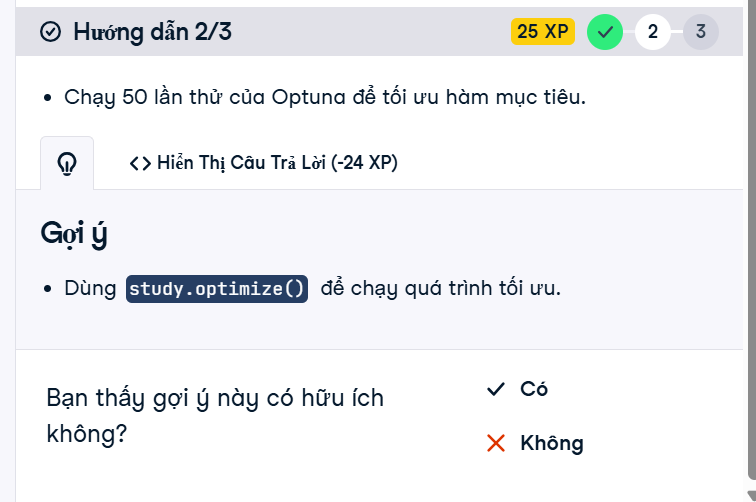

In [ ]:
"""
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = trial.suggest_float('x', -5, 5)
    y = trial.suggest_float('y', -5, 5)
    
    value = metric(x, y)
    return value

# Run 50 trials to optimize the objective function
study.optimize(objective, 50)

"""

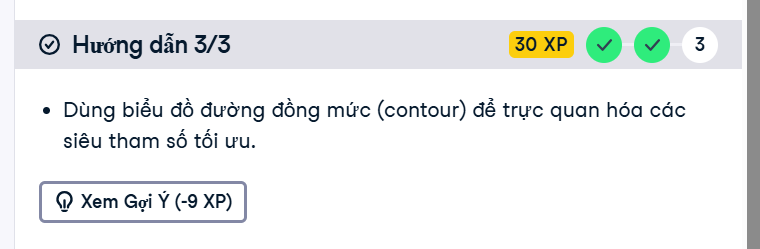

In [ ]:
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = trial.suggest_float('x', -5, 5)
    y = trial.suggest_float('y', -5, 5)
    
    value = metric(x, y)
    return value

# Run 50 trials to optimize the objective function
study.optimize(objective, 50)

# Visualize the trials using a contour plot
fig = optuna.visualization.____
fig.show()

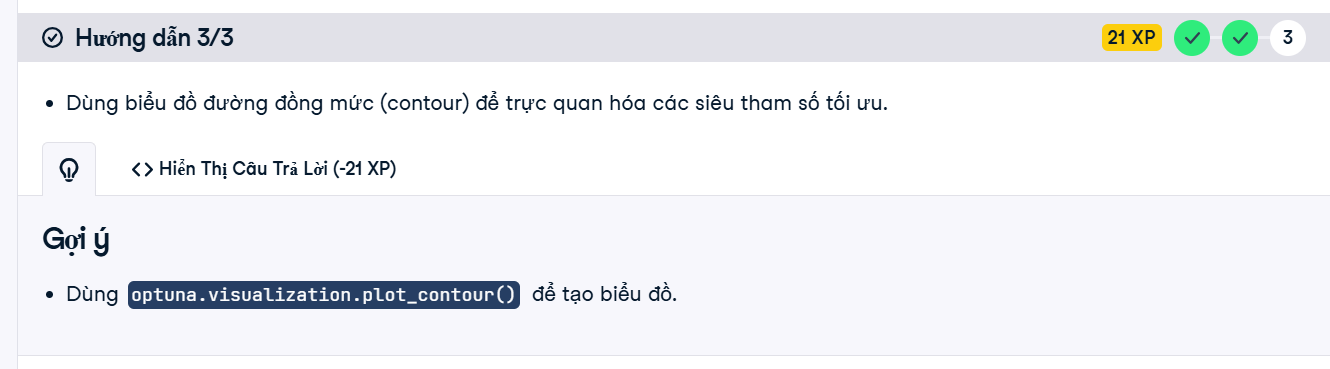

In [ ]:
"""
study = optuna.create_study()

def objective(trial: optuna.Trial):
    # Declare hyperparameters x and y as uniform
    x = trial.suggest_float('x', -5, 5)
    y = trial.suggest_float('y', -5, 5)
    
    value = metric(x, y)
    return value

# Run 50 trials to optimize the objective function
study.optimize(objective, 50)

# Visualize the trials using a contour plot
fig = optuna.visualization.plot_contour(study)
fig.show()

"""